## Connecting to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Moving Files from Drive to Colab for faster execution

In [12]:
!cp -r /content/drive/MyDrive/ContentRecognition/image_dataset /content/

## Importing Libraries

In [2]:
import os
import random
import torch
import torch.nn as nn
from transformers import DistilBertTokenizer, DistilBertModel
from torchvision import models
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

## Selecting device (CPU or GPU)
If GPU is not available then use CPU

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Define classes

In [4]:
selected_classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

## Create word pools per class

Domain-specific words, acts like semantic representation

In [ ]:
class_word_pools = {
    'buildings': ["tall", "urban", "building", "architecture", "city",
                  "construction", "structure", "skyscraper", "wall", "concrete",
                  "stone", "view", "landscape", "open", "area"],   # ← added ambiguous

    'forest'   : ["dense", "green", "trees", "forest", "nature",
                  "outdoor", "woodland", "leaves", "jungle", "wild",
                  "mountain", "cold", "dark", "rocky", "landscape"],  # ← mountain/glacier words

    'glacier'  : ["ice", "cold", "frozen", "glacier", "snow",
                  "arctic", "blue", "mountain", "frost", "icy",
                  "rocky", "peak", "water", "wide", "landscape"],  # ← mountain/sea words

    'mountain' : ["rocky", "mountain", "peak", "landscape", "outdoor",
                  "summit", "cliff", "highland", "steep", "altitude",
                  "forest", "cold", "glacier", "dark", "nature"],  # ← forest/glacier words

    'sea'      : ["ocean", "water", "waves", "beach", "coastal",
                  "blue", "shore", "marine", "horizon", "sea",
                  "open", "wide", "light", "natural", "view"],    # ← generic words
    'street'   : ["road", "street", "urban", "traffic", "city",
              "pavement", "sidewalk", "lane", "intersection", "pedestrian",
              "building", "structure", "area", "concrete", "wall"]  # ← building words
}

## Add shared ambiguous words
Makes text less perfect, simulates real-world noise

In [ ]:
shared_words = ["outdoor", "light", "dark", "wide", "narrow",
                "large", "small", "natural", "open", "view",
                "landscape", "environment", "scene", "area", "place",
                "rocky", "blue", "cold", "green", "water",   # ← these overlap with class words!
                "high", "low", "distant", "cloudy", "clear"]

## Generate mixed descriptions

For each class:
- 3 words from correct class
- 2 word from another class
- 1 ambiguous word

In [ ]:
# More noisy description generator
def generate_random_description(cls, num_words=5):
    # Only 3 correct words
    own_words = random.sample(class_word_pools[cls], 3)

    # 2 words from a random OTHER class
    other_classes = [c for c in selected_classes if c != cls]
    other_class   = random.choice(other_classes)
    other_words   = random.sample(class_word_pools[other_class], 2)

    # 1 shared ambiguous word
    shared = random.sample(shared_words, 1)

    all_words = own_words + other_words + shared
    random.shuffle(all_words)
    return " ".join(all_words)

## Test — verify mixed words

In [8]:


print("Testing descriptions (notice mixed words):")
for cls in selected_classes:
    d1 = generate_random_description(cls)
    d2 = generate_random_description(cls)
    print(f"{cls:12} → '{d1}'")
    print(f"{'':12}   '{d2}'")
    print()

Testing descriptions (notice mixed words):
buildings    → 'building place snow city construction'
               'tall skyscraper wall view shore'

forest       → 'view waves jungle woodland trees'
               'trees environment wild pedestrian woodland'

glacier      → 'cliff arctic dark mountain glacier'
               'glacier icy altitude frozen outdoor'

mountain     → 'concrete peak steep rocky open'
               'cliff peak steep nature environment'

sea          → 'light mountain beach shore ocean'
               'shore waves sea jungle small'

street       → 'urban outdoor pedestrian highland intersection'
               'narrow city street steep pedestrian'



## Create ResNet50 architecture

In [ ]:
resnet = models.resnet50(pretrained=False)

```pretrained=False```means: Do NOT load ImageNet weights as we have already trained the model and we upload our model weights

## Classifier

2048 → 256 → 6 classes

In [ ]:
resnet.fc = nn.Sequential(
    nn.Linear(resnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 6)
)

## Load your trained weights

In [ ]:
resnet.load_state_dict(torch.load(
    '/content/drive/MyDrive/ContentRecognition/checkpoints/best_model.pth',
    map_location=device
))

## Remove classifier

Removes: final FC classification layer

Now output becomes: (batch, 2048, 1, 1)

In [ ]:
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])

## Move to GPU

In [ ]:
feature_extractor = feature_extractor.to(device)

## Freeze all parameters

No training happens now

ResNet acts only as: fixed feature extractor

In [ ]:
for param in feature_extractor.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet50 loaded from checkpoint — frozen!


## Evaluation mode

In [ ]:
feature_extractor.eval()
print("ResNet50 loaded from checkpoint — frozen!")

## Load tokenizer

converts text → tokens → IDs

In [ ]:
tokenizer  = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

## Load DistilBERT model and move to GPU/CPU

In [ ]:
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)

## Freeze BERT

It prevents training

BERT acts only as text feature extractor

In [ ]:
for param in bert_model.parameters():
    param.requires_grad = False

## Evaluation mode

In [ ]:
bert_model.eval()

## Sentence -> numerical vector

In [ ]:

def get_text_features(text):
    tokens = tokenizer(             # Converts text into token IDs
        text,
        return_tensors='pt',        # Returns PyTorch tensors
        padding=True,               # Makes all sentences same length
        truncation=True,            # Cuts long sentences
        max_length=32               # Max 32 tokens allowed
    ).to(device)                    # Move tokens to GPU
    with torch.no_grad():
        output = bert_model(**tokens)       # Pass tokens through BERT
    # Output shape:(batch, sequence_length, 768)
    return output.last_hidden_state[:, 0, :]    # Selects first token embedding which Represents whole sentence meaning
print("DistilBERT loaded and frozen!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded and frozen!


## Define FusionHead class

It only:
- receives image features
- receives text features
- combines them

In [ ]:
class FusionHead(nn.Module):
    def __init__(self, num_classes=6):
        super(FusionHead, self).__init__()

        # Take resnet 2048 features and map to 512
        self.visual_projector = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.3)
        )

        # Take BERT embedding of size 768 map to 512
        self.text_projector = nn.Sequential(
            nn.Linear(768, 512), nn.ReLU(), nn.Dropout(0.3)
        )

        # Takes 512 + 512 = 1024 features then map to 256 then to 6 classes
        self.fusion = nn.Sequential(
            nn.Linear(1024, 256), 
            nn.ReLU(), 
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    # Forward function
    def forward(self, image_feat, text_feat):
        v = self.visual_projector(image_feat)   # (batch, 512)
        t = self.text_projector(text_feat)      # (batch, 512)
        delta = 0.6                         # trust image 60%, text 40%
        fused = delta * v + (1 - delta) * t # (batch, 512)

        return self.fusion(fused)

fusion_model = FusionHead(num_classes=6).to(device)
print("Fusion head ready!")
print(f"Trainable params: {sum(p.numel() for p in fusion_model.parameters() if p.requires_grad):,}")

Fusion head ready!
Trainable params: 1,706,758


In [14]:
class ImageTextDataset(Dataset):
    def __init__(self, samples, selected_classes,
                 transform=None, training=False):
        self.samples          = samples
        self.selected_classes = selected_classes
        self.transform        = transform
        self.training         = training

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        cls_name        = self.selected_classes[label]

        # Load image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Generate text description
        if self.training:
            num_words = random.randint(4, 6)
            desc      = generate_random_description(cls_name, num_words)
        else:
            random.seed(idx)
            desc = generate_random_description(cls_name, 5)
            random.seed()

        text_feat = get_text_features(desc).squeeze(0)

        return image, text_feat, label

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Build samples
train_path   = '/content/image_dataset/seg_train/seg_train'
val_path     = '/content/image_dataset/seg_test/seg_test'
class_to_idx = {cls: idx for idx, cls in enumerate(selected_classes)}

def build_samples(root_path, class_to_idx):
    samples = []
    for cls, idx in class_to_idx.items():
        cls_path = os.path.join(root_path, cls)
        if not os.path.exists(cls_path):
            print(f"Missing: {cls}")
            continue
        for img_file in os.listdir(cls_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                samples.append((os.path.join(cls_path, img_file), idx))
    return samples

train_samples = build_samples(train_path, class_to_idx)
val_samples   = build_samples(val_path,   class_to_idx)

print(f"Train samples: {len(train_samples)}")
print(f"Val samples  : {len(val_samples)}")

# Datasets
train_dataset = ImageTextDataset(train_samples, selected_classes,
                                  train_transforms, training=True)
val_dataset   = ImageTextDataset(val_samples,   selected_classes,
                                  val_transforms,   training=False)

# ✅ num_workers=0 because of dynamic BERT calls
train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=0)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train samples: 14034
Val samples  : 3000

Train batches: 439
Val batches  : 94


In [16]:
# CELL 10 — Train fusion head only
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fusion_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

EPOCHS          = 5
best_val_acc    = 0.0
checkpoint_path = '/content/drive/MyDrive/ContentRecognition/checkpoints/fusion_best.pth'

history = {'train_loss': [], 'val_loss': [],
           'train_acc' : [], 'val_acc' : []}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    for phase in ['train', 'val']:
        if phase == 'train':
            fusion_model.train()
            loader = train_loader
        else:
            fusion_model.eval()
            loader = val_loader

        running_loss, running_corrects = 0.0, 0

        for images, text_feats, labels in loader:
            images     = images.to(device)
            text_feats = text_feats.to(device)
            labels     = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):

                # Step 1 — Extract image features from frozen ResNet
                with torch.no_grad():
                    img_feat = feature_extractor(images)
                    img_feat = img_feat.view(img_feat.size(0), -1)  # (batch, 2048)

                # Step 2 — Pass through fusion head
                outputs  = fusion_model(img_feat, text_feats)
                loss     = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss     += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()

        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc  = running_corrects.double() / len(loader.dataset)

        print(f"{phase.upper()} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

            if epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                torch.save(fusion_model.state_dict(), checkpoint_path)
                print(f"  ✅ Best fusion model saved! Val Acc: {best_val_acc:.4f}")

print(f"\nTraining Complete! Best Val Acc: {best_val_acc:.4f}")


Epoch 1/5
----------------------------------------
TRAIN — Loss: 0.1858  Acc: 0.9352
VAL — Loss: 0.0483  Acc: 0.9820
  ✅ Best fusion model saved! Val Acc: 0.9820

Epoch 2/5
----------------------------------------
TRAIN — Loss: 0.0497  Acc: 0.9847
VAL — Loss: 0.0314  Acc: 0.9863
  ✅ Best fusion model saved! Val Acc: 0.9863

Epoch 3/5
----------------------------------------
TRAIN — Loss: 0.0423  Acc: 0.9857
VAL — Loss: 0.0167  Acc: 0.9930
  ✅ Best fusion model saved! Val Acc: 0.9930

Epoch 4/5
----------------------------------------
TRAIN — Loss: 0.0201  Acc: 0.9934
VAL — Loss: 0.0132  Acc: 0.9957
  ✅ Best fusion model saved! Val Acc: 0.9957

Epoch 5/5
----------------------------------------
TRAIN — Loss: 0.0187  Acc: 0.9936
VAL — Loss: 0.0115  Acc: 0.9967
  ✅ Best fusion model saved! Val Acc: 0.9967

Training Complete! Best Val Acc: 0.9967


Classification Report:
              precision    recall  f1-score   support

   buildings       0.99      1.00      1.00       437
      forest       1.00      1.00      1.00       474
     glacier       1.00      1.00      1.00       553
    mountain       1.00      1.00      1.00       525
         sea       1.00      1.00      1.00       510
      street       1.00      0.99      0.99       501

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



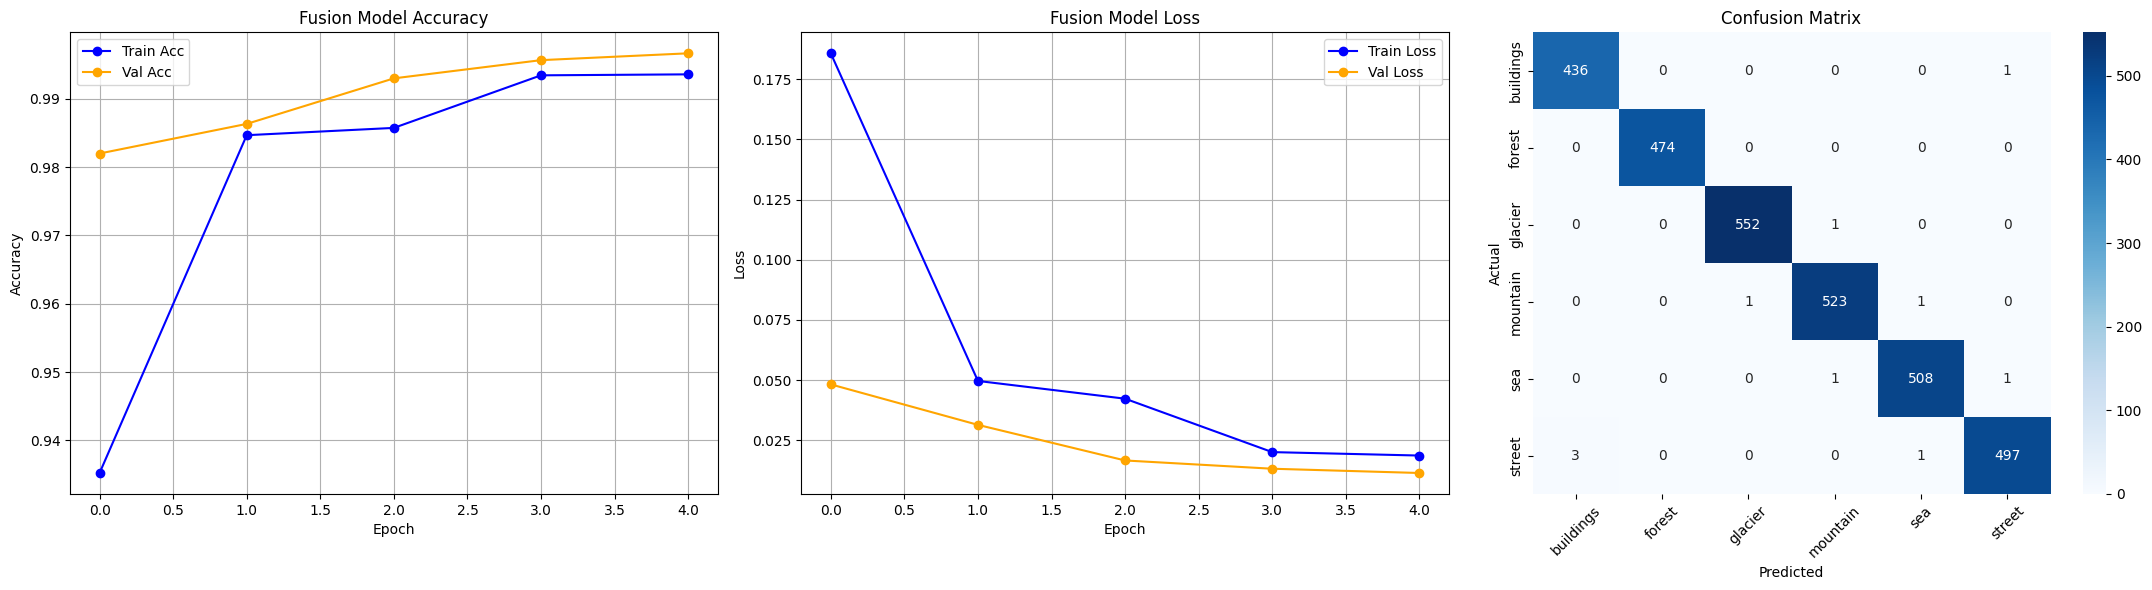

Results saved to Drive!


In [18]:
# CELL 11 — Evaluation + plots
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best fusion model
fusion_model.load_state_dict(torch.load(checkpoint_path))
fusion_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, text_feats, labels in val_loader:
        images     = images.to(device)
        text_feats = text_feats.to(device)

        # Extract image features
        img_feat = feature_extractor(images)
        img_feat = img_feat.view(img_feat.size(0), -1)

        # Predict
        outputs  = fusion_model(img_feat, text_feats)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=selected_classes))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Accuracy plot
axes[0].plot(history['train_acc'], label='Train Acc', marker='o', color='blue')
axes[0].plot(history['val_acc'],   label='Val Acc',   marker='o', color='orange')
axes[0].set_title('Fusion Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history['train_loss'], label='Train Loss', marker='o', color='blue')
axes[1].plot(history['val_loss'],   label='Val Loss',   marker='o', color='orange')
axes[1].set_title('Fusion Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_classes,
            yticklabels=selected_classes,
            ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ContentRecognition/fusion_results.png', dpi=150)
plt.show()
print("Results saved to Drive!")

In [20]:
# CELL 12 — Gradio Demo
!pip install gradio -q

import gradio as gr
import torch.nn.functional as F

def predict_image(image, description):
    try:
        if image is None:
            return "Please upload an image", None

        # Prepare image
        image        = Image.fromarray(image).convert('RGB')
        image_tensor = val_transforms(image).unsqueeze(0).to(device)

        # Use default text if empty
        if not description or description.strip() == "":
            description = "outdoor natural scene landscape view"

        # Get features
        with torch.no_grad():
            img_feat  = feature_extractor(image_tensor)
            img_feat  = img_feat.view(img_feat.size(0), -1)
            text_feat = get_text_features(description).to(device)
            output    = fusion_model(img_feat, text_feat)
            probs     = F.softmax(output, dim=1)[0]

        pred_idx   = probs.argmax().item()
        pred_class = selected_classes[pred_idx]
        confidence = probs[pred_idx].item() * 100

        # Build confidence scores dict for bar chart
        scores = {cls: round(float(probs[i].item()) * 100, 2)
                  for i, cls in enumerate(selected_classes)}

        result = f"Predicted: {pred_class.upper()}\nConfidence: {confidence:.2f}%"
        return result, scores

    except Exception as e:
        return f"Error: {str(e)}", None

# Build Gradio UI
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # Deep Learning News Image Content Recognition
    ### Multimodal Fusion — ResNet50 + DistilBERT
    Upload an image and optionally add a text description.
    """)

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(label="Upload Image", height=300)
            text_input  = gr.Textbox(
                label="Image Description (optional)",
                placeholder="e.g. tall buildings in city urban area",
                lines=2
            )
            predict_btn = gr.Button("Predict", variant="primary")

        with gr.Column():
            result_output = gr.Textbox(label="Prediction Result",
                                       lines=3, interactive=False)
            prob_output   = gr.Label(label="Class Probabilities",
                                     num_top_classes=6)

    gr.Markdown("""
    ### Supported Classes
    `buildings` • `forest` • `glacier` • `mountain` • `sea` • `street`

    ### Example Descriptions
    - buildings → *"tall urban skyscraper city architecture"*
    - forest    → *"dense green trees woodland nature"*
    - glacier   → *"ice frozen cold arctic snow"*
    - mountain  → *"rocky peak summit highland steep"*
    - sea       → *"ocean waves beach coastal marine"*
    - street    → *"road traffic urban sidewalk lane"*
    """)

    predict_btn.click(
        fn      = predict_image,
        inputs  = [image_input, text_input],
        outputs = [result_output, prob_output]
    )

demo.launch(share=True, debug=True)

/tmp/ipykernel_880/1939724056.py:43: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1f06aa5331bcd72076.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1f06aa5331bcd72076.gradio.live
